In [1]:
import pandas as pd
import hourly_disaggregation
from pathlib import Path

In [2]:
from hourly_disaggregation import run_pipeline, plot_profiles, plot_week_comparison, plot_error_heatmap

# FR regions

In [3]:
CONSO_PATH = "base_data/FR_elec/conso_reg_hourly.csv"
TEMP_PATH  = "base_data/temp_era/temp_FR_hourly_era.csv"

OUTPUT_DIR = Path("outputs_hourly/Occitanie")
OUTPUT_DIR.mkdir(exist_ok=True)

In [4]:
result = run_pipeline(CONSO_PATH, TEMP_PATH,
                        eval_years=[2016, 2019, 2025],
                        exclude_years = [2016, 2019, 2020, 2021, 2025])

conso    = result["conso"]
profiles = result["profiles"]

PIPELINE DÉSAGRÉGATION HORAIRE — ÉTAPE 1
[load] conso_reg_hourly.csv : 13 timestamp(s) dupliqué(s) retirés (probablement changements d'heure)
[load] Conso : 2013-01-01 00:00:00 → 2026-01-01 23:00:00  |  113,963 lignes  |  12 régions
[load] temp_FR_hourly_era.csv : 16 timestamp(s) dupliqué(s) retirés (probablement changements d'heure)
[load] Temp  : 2010-01-01 01:00:00 → 2026-01-01 00:00:00  |  140,240 lignes  |  12 régions

[1/3] Calcul des profils normalisés…
  Années exclues de l'entraînement : [2016, 2019, 2020, 2021, 2025]
  ✓ 12 régions, 20 profils/région

[2/3] Évaluation par année…

--- 2016 ---
                             RMSE    MAE  MAPE_%      R2     N
region                                                        
Auvergne-Rhône-Alpes        220.6  162.0    2.09  0.9798  8736
Bourgogne-Franche-Comté      76.3   56.8    2.32  0.9807  8736
Bretagne                    103.3   76.5    2.99  0.9749  8736
Centre-Val de Loire          81.5   61.8    2.92  0.9774  8736
Grand Est   

  → outputs_hourly\Occitanie\profiles_Occitanie.png


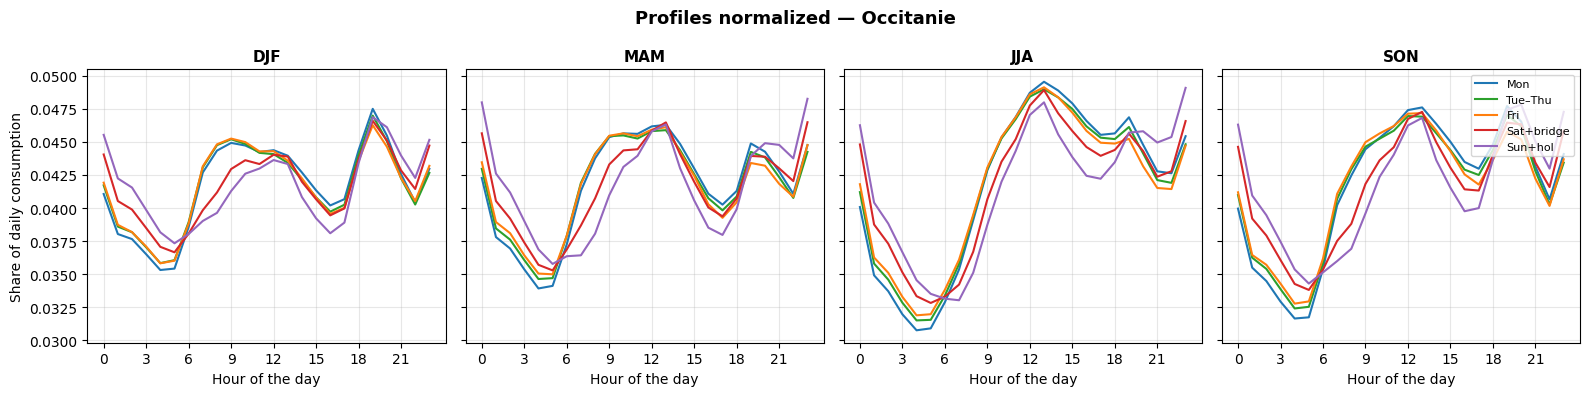

In [5]:
region_demo = "Occitanie"

plot_profiles(profiles, region_demo,
                save=OUTPUT_DIR / f"profiles_{region_demo}.png")

  → outputs_hourly\Occitanie\week_winter_Occitanie.png


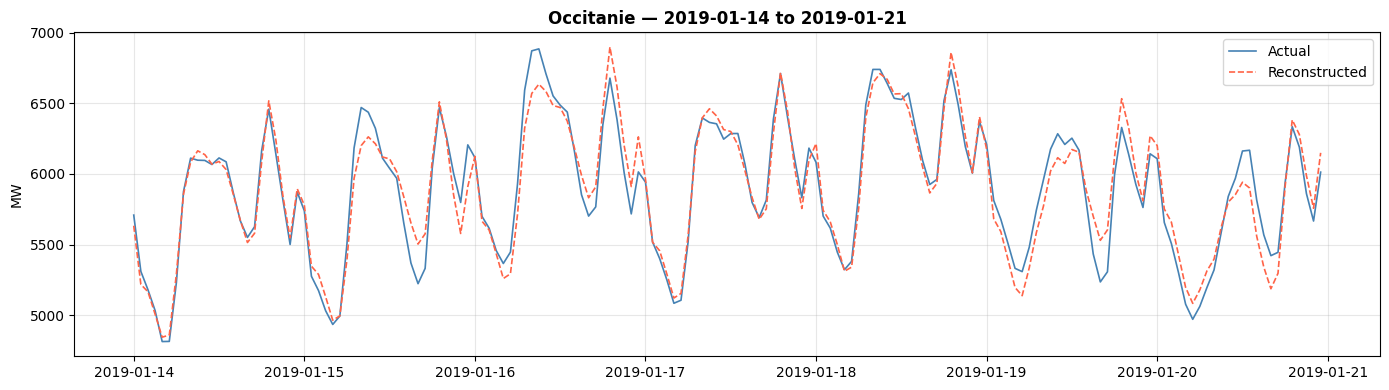

  → outputs_hourly\Occitanie\week_summer_Occitanie.png


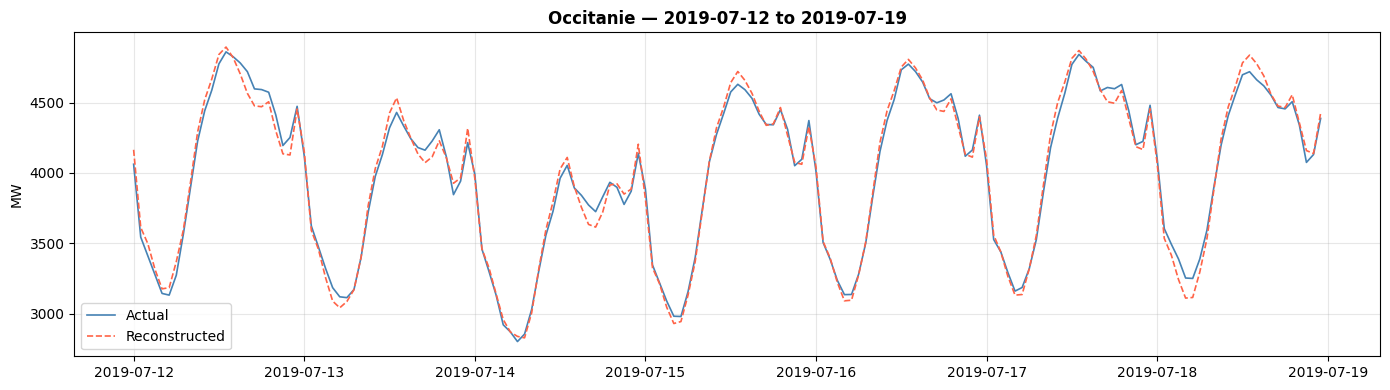

In [6]:
plot_week_comparison(conso, profiles, region_demo,
                        start_date="2019-01-14", n_days=7,
                        save=OUTPUT_DIR / f"week_winter_{region_demo}.png")

# Semaine type été
plot_week_comparison(conso, profiles, region_demo,
                        start_date="2019-07-12", n_days=7,
                        save=OUTPUT_DIR / f"week_summer_{region_demo}.png")

  → outputs_hourly\Occitanie\heatmap_err_Occitanie.png


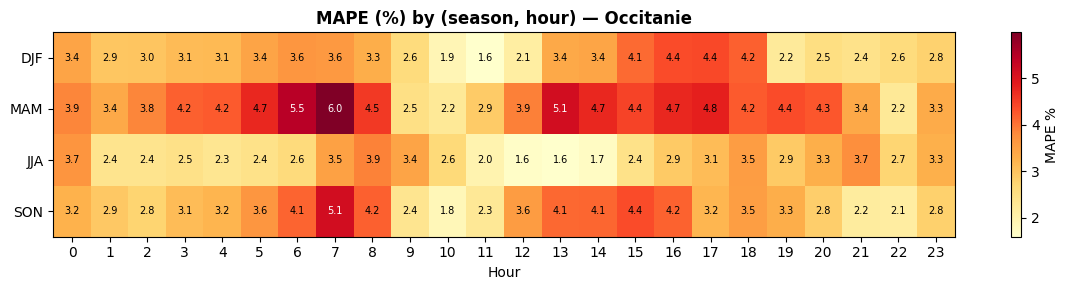

In [7]:
# Heatmap erreur
plot_error_heatmap(conso, profiles, region_demo, years=[2019, 2023, 2024],
                    save=OUTPUT_DIR / f"heatmap_err_{region_demo}.png")

### Residuals

In [8]:
from hourly_disaggregation import plot_residuals_diagnostics, plot_residuals_by_typology, plot_residuals_by_hour_season

  → outputs_hourly\Occitanie\residuals_Occitanie.png


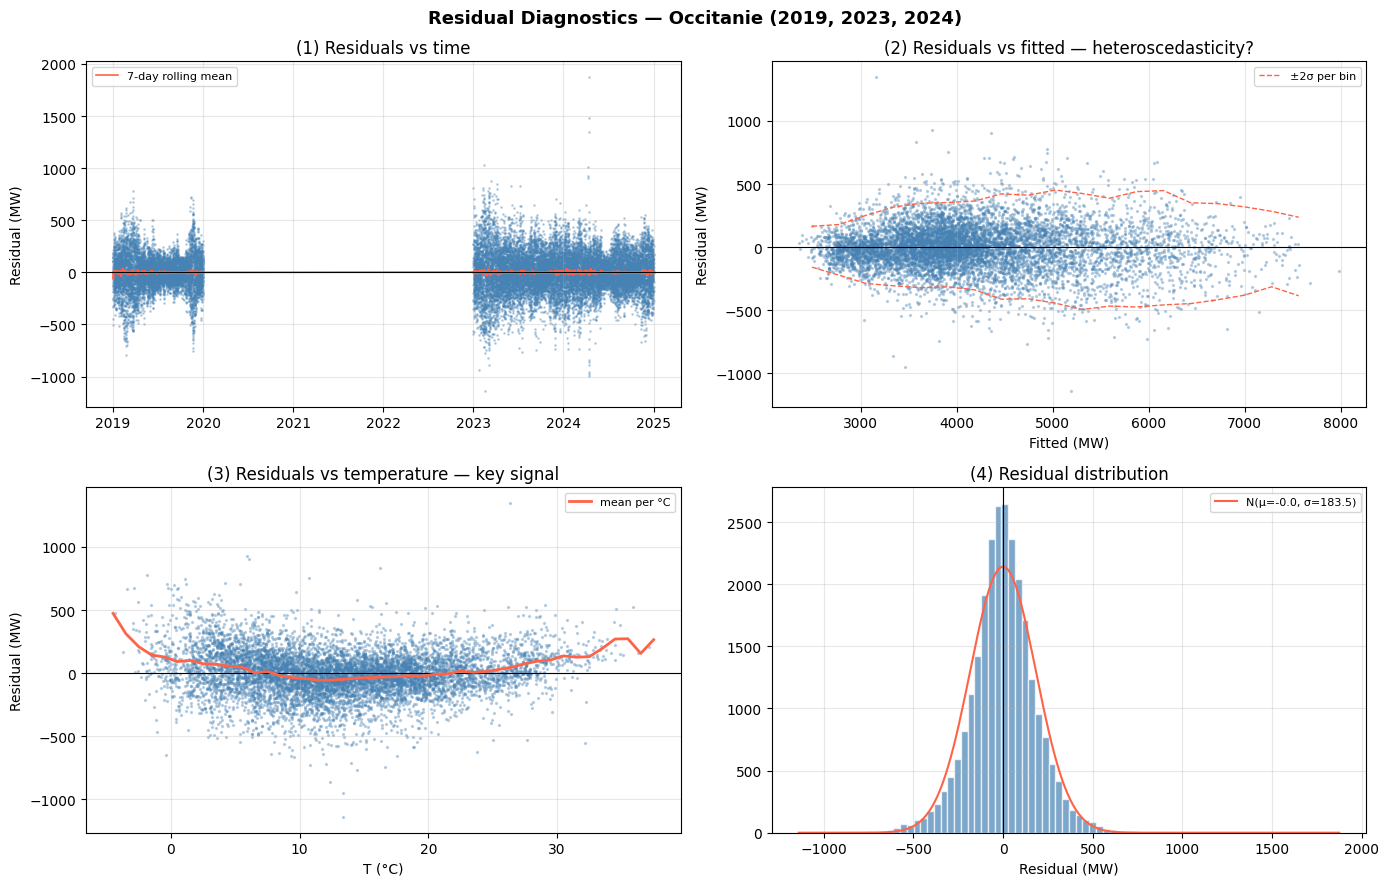


Residual summary — Occitanie
  mean        :    -0.00 MW  (should be close to 0)
  std dev     :   183.54 MW
  skewness    :    0.032  (symmetry: 0 = perfect, >0 = right tail)
  kurtosis    :    2.160  (tails: 0 = normal, >0 = heavy tails)
  global MAPE :     3.30 %
  → outputs_hourly\Occitanie\residuals_typology_Occitanie.png


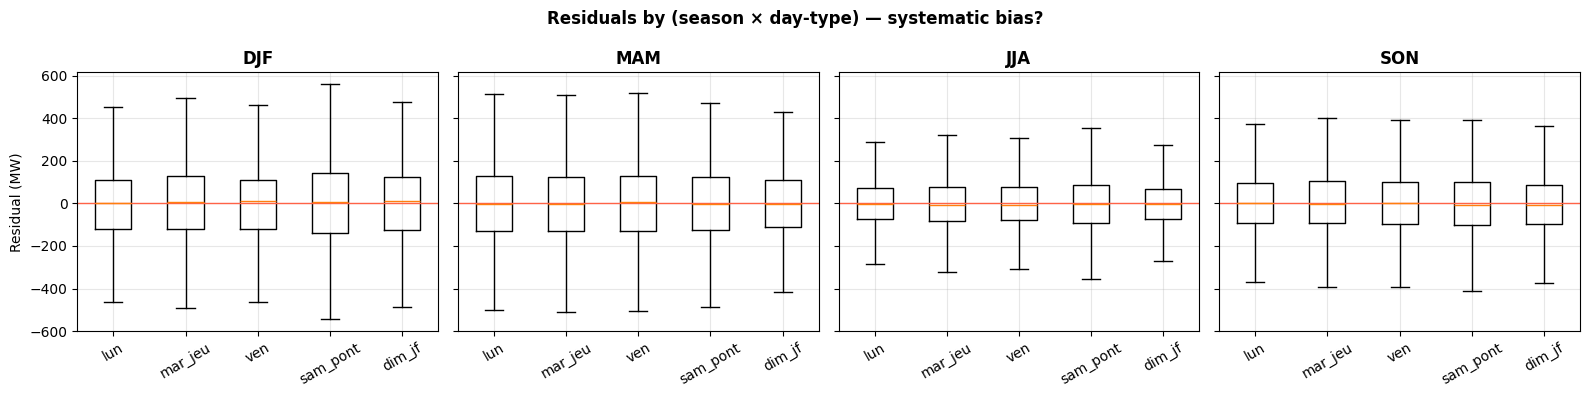

  → outputs_hourly\Occitanie\residuals_signed_Occitanie.png


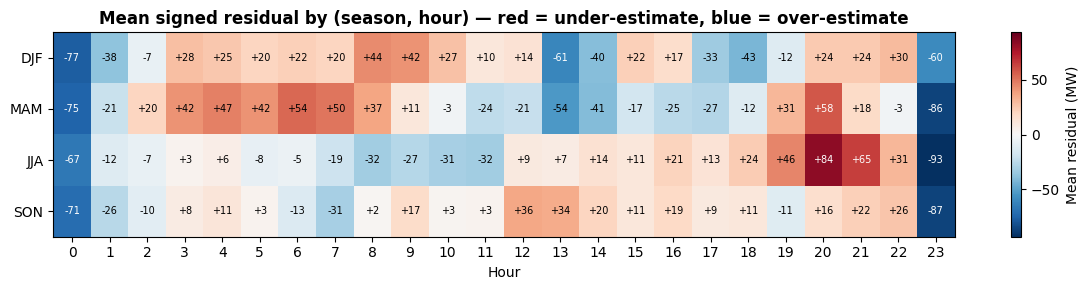

In [9]:
temp = result.get("temp")
res = plot_residuals_diagnostics(
    conso, profiles, region_demo,
    years=[2019, 2023, 2024],
    temp_hourly=temp,
    save=OUTPUT_DIR / f"residuals_{region_demo}.png",
)
plot_residuals_by_typology(
    res, save=OUTPUT_DIR / f"residuals_typology_{region_demo}.png"
)
plot_residuals_by_hour_season(
    res, save=OUTPUT_DIR / f"residuals_signed_{region_demo}.png"
)

# EU countries

In [10]:
CONSO_PATH = "base_data/EU/conso_EU_hourly.csv"
TEMP_PATH  = "base_data/temp_era/temp_EU_hourly_era.csv"

OUTPUT_DIR = Path("outputs_hourly/EU")
OUTPUT_DIR.mkdir(exist_ok=True)

In [11]:
result = run_pipeline(CONSO_PATH, TEMP_PATH,
                        eval_years=[2019, 2023, 2024])

conso    = result["conso"]
profiles = result["profiles"]

PIPELINE DÉSAGRÉGATION HORAIRE — ÉTAPE 1
[load] conso_EU_hourly.csv : 2 timestamp(s) dupliqué(s) retirés (probablement changements d'heure)
[load] Conso : 2016-01-01 01:00:00 → 2026-01-01 00:00:00  |  81,124 lignes  |  9 régions
[load] temp_EU_hourly_era.csv : 16 timestamp(s) dupliqué(s) retirés (probablement changements d'heure)
[load] Temp  : 2010-01-01 01:00:00 → 2026-01-01 00:00:00  |  140,240 lignes  |  10 régions

[1/3] Calcul des profils normalisés…
  Années exclues de l'entraînement : [2020, 2021]
  ✓ 9 régions, 20 profils/région

[2/3] Évaluation par année…

--- 2019 ---
          RMSE     MAE  MAPE_%      R2     N
region                                      
BE       227.6   170.9    1.78  0.9710  8544
CH       324.0   252.5    3.98  0.8694  8544
DE      1313.6   903.0    1.67  0.9825  8544
ES       778.8   590.1    2.08  0.9704  8544
IT      1116.4   758.6    2.41  0.9792  8544
UK      1497.3  1100.2    3.81  0.9483  8544
IE        94.2    70.3    2.18  0.9757  8544
NL      

In [12]:
for country in profiles.keys():
    profiles[country].to_csv(f"final_predictions/hourly_profiles/EU/{country}_profiles.csv")
